Name: Nishan

Course: Advanced Big Data and Data Mining

Lab Assignment: Data Visualization, Preprocessing and Statistical Analysis


In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

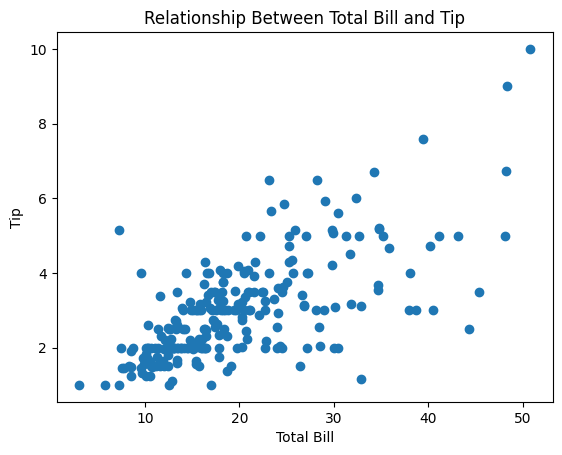

In [3]:
plt.scatter(df['total_bill'], df['tip'])

plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("Relationship Between Total Bill and Tip")

plt.show()


Insight:
The scatter plot shows the relationship between total bill and tip amount.
Customers with higher bills tend to leave higher tips, indicating a positive
relationship between total bill and tip.

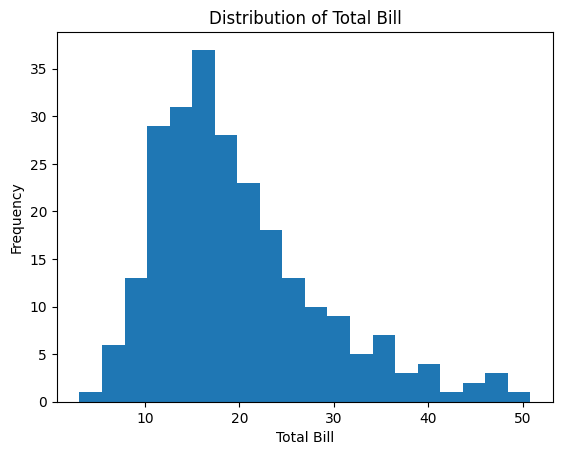

In [4]:
plt.hist(df['total_bill'], bins=20)

plt.xlabel("Total Bill")
plt.ylabel("Frequency")
plt.title("Distribution of Total Bill")

plt.show()


Insight:
The histogram shows the distribution of total bill values. Most bills fall
between the mid-range values, while very large bills occur less frequently

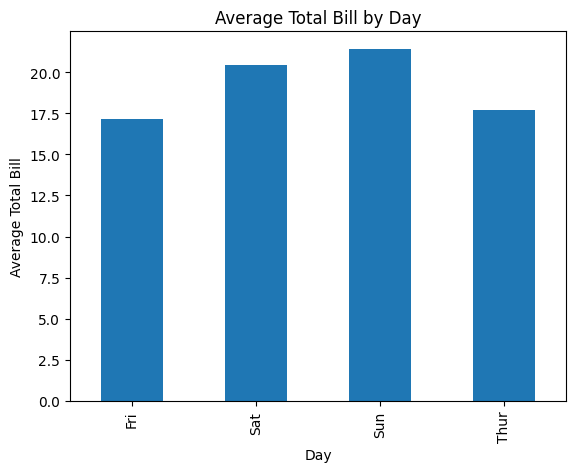

In [5]:
df.groupby('day')['total_bill'].mean().plot(kind='bar')

plt.xlabel("Day")
plt.ylabel("Average Total Bill")
plt.title("Average Total Bill by Day")

plt.show()


Insight:
The bar chart compares the average total bill across different days.
This helps identify which days tend to have higher spending at the restaurant.

In [6]:
df.isnull().sum()


,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


In [7]:
df.fillna(df.mean(numeric_only=True), inplace=True)

df.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [9]:
Q1 = df['total_bill'].quantile(0.25)
Q3 = df['total_bill'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)


Q1: 13.3475
Q3: 24.127499999999998
IQR: 10.779999999999998
Lower Bound: -2.8224999999999945
Upper Bound: 40.29749999999999


In [10]:
outliers = df[(df['total_bill'] < lower_bound) | (df['total_bill'] > upper_bound)]

outliers


,total_bill,tip,sex,smoker,day,time,size
59,48.27,6.73,Male,No,Sat,Dinner,4
102,44.30,2.50,Female,Yes,Sat,Dinner,3
142,41.19,5.00,Male,No,Thur,Lunch,5
156,48.17,5.00,Male,No,Sun,Dinner,6
170,50.81,10.00,Male,Yes,Sat,Dinner,3
182,45.35,3.50,Male,Yes,Sun,Dinner,3
184,40.55,3.00,Male,Yes,Sun,Dinner,2
197,43.11,5.00,Female,Yes,Thur,Lunch,4
212,48.33,9.00,Male,No,Sat,Dinner,4


In [11]:
df_clean = df[(df['total_bill'] >= lower_bound) & (df['total_bill'] <= upper_bound)]

df_clean.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [12]:
df_sample = df.sample(frac=0.5)

df_sample.head()


,total_bill,tip,sex,smoker,day,time,size
2,21.01,3.50,Male,No,Sun,Dinner,3
79,17.29,2.71,Male,No,Thur,Lunch,2
146,18.64,1.36,Female,No,Thur,Lunch,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
52,34.81,5.20,Female,No,Sun,Dinner,4


In [13]:
df_reduced = df.drop(columns=['time'])

df_reduced.head()


,total_bill,tip,sex,smoker,day,size
0,16.99,1.01,Female,No,Sun,2
1,10.34,1.66,Male,No,Sun,3
2,21.01,3.50,Male,No,Sun,3
3,23.68,3.31,Male,No,Sun,2
4,24.59,3.61,Female,No,Sun,4


In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df['scaled_bill'] = scaler.fit_transform(df[['total_bill']])

df.head()


,total_bill,tip,sex,smoker,day,time,size,scaled_bill
0,16.99,1.01,Female,No,Sun,Dinner,2,0.291579
1,10.34,1.66,Male,No,Sun,Dinner,3,0.152283
2,21.01,3.50,Male,No,Sun,Dinner,3,0.375786
3,23.68,3.31,Male,No,Sun,Dinner,2,0.431713
4,24.59,3.61,Female,No,Sun,Dinner,4,0.450775


In [15]:
df['bill_category'] = pd.cut(df['total_bill'],
                             bins=3,
                             labels=['Low','Medium','High'])

df[['total_bill','bill_category']].head()


,total_bill,bill_category
0,16.99,Low
1,10.34,Low
2,21.01,Medium
3,23.68,Medium
4,24.59,Medium


In [16]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   total_bill     244 non-null    float64 
 1   tip            244 non-null    float64 
 2   sex            244 non-null    object  
 3   smoker         244 non-null    object  
 4   day            244 non-null    object  
 5   time           244 non-null    object  
 6   size           244 non-null    int64   
 7   scaled_bill    244 non-null    float64 
 8   bill_category  244 non-null    category
dtypes: category(1), float64(3), int64(1), object(4)
memory usage: 15.7+ KB


In [17]:
df.describe()


,total_bill,tip,size,scaled_bill
count,244.000000,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672,0.350145
std,8.902412,1.383638,0.951100,0.186477
min,3.070000,1.000000,1.000000,0.000000
25%,13.347500,2.000000,2.000000,0.215281
50%,17.795000,2.900000,2.000000,0.308442
75%,24.127500,3.562500,3.000000,0.441087
max,50.810000,10.000000,6.000000,1.000000


In [18]:
print("Minimum:", df['total_bill'].min())
print("Maximum:", df['total_bill'].max())
print("Mean:", df['total_bill'].mean())
print("Median:", df['total_bill'].median())
print("Mode:", df['total_bill'].mode()[0])


Minimum: 3.07
Maximum: 50.81
Mean: 19.78594262295082
Median: 17.795
Mode: 13.42


In [19]:
range_value = df['total_bill'].max() - df['total_bill'].min()

print("Range:", range_value)
print("Quartiles:")
print(df['total_bill'].quantile([0.25, 0.5, 0.75]))

print("Variance:", df['total_bill'].var())
print("Standard Deviation:", df['total_bill'].std())


Range: 47.74
Quartiles:
0.25    13.3475
0.50    17.7950
0.75    24.1275
Name: total_bill, dtype: float64
Variance: 79.25293861397826
Standard Deviation: 8.902411954856856


In [20]:
df.corr(numeric_only=True)


,total_bill,tip,size,scaled_bill
total_bill,1.000000,0.675734,0.598315,1.000000
tip,0.675734,1.000000,0.489299,0.675734
size,0.598315,0.489299,1.000000,0.598315
scaled_bill,1.000000,0.675734,0.598315,1.000000


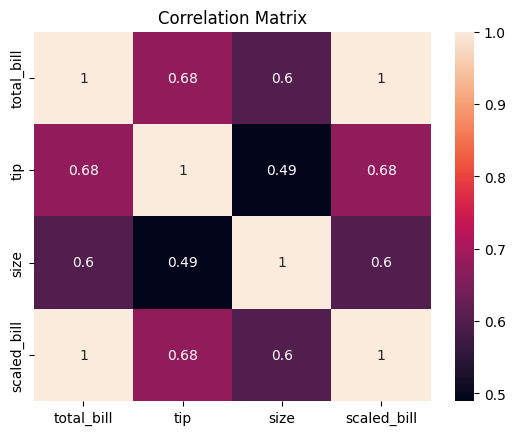

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()
